# Human Activity Recognition using Hidden Markov Models (HMM)

This notebook implements a Hidden Markov Model to recognize human activities using smartphone accelerometer and gyroscope data. Activities include standing, walking, jumping, and still. The model is trained on collected sensor data and evaluated using unseen test recordings.

In [ ]:
!pip install hmmlearn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\tracy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Load Training Dataset
The merged dataset contains accelerometer and gyroscope signals collected during the four activities.

In [ ]:
import pandas as pd

df = pd.read_csv("MERGED/all_merged_sessions.csv")

print(df.columns)

Index(['time', 'seconds_elapsed_x', 'acc_x', 'acc_y', 'acc_z',
       'seconds_elapsed_y', 'gyro_x', 'gyro_y', 'gyro_z', 'member', 'activity',
       'trial', 'session_id'],
      dtype='object')


## Sampling Rate Analysis
We estimate the sampling rate of the sensor recordings by calculating the average time difference between consecutive measurements.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("MERGED/all_merged_sessions.csv")

session = df["session_id"].unique()[0]
session_df = df[df["session_id"] == session].copy()

time_diff = session_df["seconds_elapsed_x"].diff().dropna()
sampling_rate = 1 / time_diff.mean()

print("Sampling rate:", sampling_rate)
print("Min dt:", time_diff.min())
print("Max dt:", time_diff.max())

Sampling rate: 99.48046726784928
Min dt: 0.010040283203125
Max dt: 0.018827392578124602


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("MERGED/all_merged_sessions.csv")

rates = []

for session_id, session_df in df.groupby("session_id"):
    session_df = session_df.sort_values("seconds_elapsed_x").copy()
    dt = session_df["seconds_elapsed_x"].diff().dropna()

    # remove impossible or zero gaps just in case
    dt = dt[dt > 0]

    if len(dt) > 0:
        rate = 1 / dt.mean()
        rates.append(rate)
        print(session_id, "->", rate)

print("\nAverage sampling rate:", np.mean(rates))
print("Median sampling rate:", np.median(rates))

best_jumping_01-2026-03-04_18-42-01 -> 99.48046726784928
best_jumping_02-2026-03-04_18-42-11 -> 99.58988976469563
best_jumping_03-2026-03-04_18-42-28 -> 99.45739207475368
best_jumping_04-2026-03-04_18-42-41 -> 99.57637889576968
best_jumping_05-2026-03-04_18-43-40 -> 99.59091072126077
best_jumping_06-2026-03-04_18-44-11 -> 99.49108845693726
best_standing_01-2026-03-04_16-44-13 -> 99.57319719507352
best_standing_02-2026-03-04_16-44-32 -> 99.54870552677653
best_standing_03-2026-03-04_16-44-45 -> 99.5733748383001
best_standing_04-2026-03-04_16-44-58 -> 99.50243889060808
best_standing_05-2026-03-04_16-45-09 -> 99.58660920370428
best_standing_06-2026-03-04_16-45-20 -> 99.54947938074392
best_still_01-2026-03-04_17-05-58 -> 99.5933886159131
best_still_02-2026-03-04_17-06-09 -> 99.47436661485193
best_still_03-2026-03-04_17-06-22 -> 99.48824469655912
best_still_04-2026-03-04_17-06-35 -> 99.51471694123168
best_still_05-2026-03-04_17-06-49 -> 99.48885942291558
best_still_06-2026-03-04_17-06-59 -> 

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("MERGED/all_merged_sessions.csv")

fs = 75   #  our median sampling rate
window_size = int(fs * 1.0)   # 1 second
step_size = int(window_size * 0.5)  # 50% overlap

windows = []

for session_id, session_df in df.groupby("session_id"):
    session_df = session_df.sort_values("seconds_elapsed_x").reset_index(drop=True)

    for start in range(0, len(session_df) - window_size + 1, step_size):
        end = start + window_size
        window = session_df.iloc[start:end].copy()

        windows.append({
            "session_id": session_id,
            "member": window["member"].iloc[0],
            "activity": window["activity"].iloc[0],
            "trial": window["trial"].iloc[0],
            "window_index": len(windows),
            "data": window
        })

print("Total windows created:", len(windows))

Total windows created: 843


## Window Segmentation
The sensor data is segmented into fixed-size windows (1 second) with 50% overlap. Each window represents a short activity segment used for feature extraction.

In [ ]:
#Feature Extraction

df = pd.read_csv("MERGED/all_merged_sessions.csv")

df["acc_mag"] = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
df["gyro_mag"] = np.sqrt(df["gyro_x"]**2 + df["gyro_y"]**2 + df["gyro_z"]**2)

df.head()

,time,seconds_elapsed_x,acc_x,acc_y,acc_z,seconds_elapsed_y,gyro_x,gyro_y,gyro_z,member,activity,trial,session_id,acc_mag,gyro_mag
0,1772649721036554200,0.026554,0.875808,-6.941425,-0.630575,0.026554,-0.026674,0.009134,-0.143933,best,jumping,01-2026-03-04,best_jumping_01-2026-03-04_18-42-01,7.024817,0.146669
1,1772649721046595300,0.036595,0.825481,-6.880710,-0.633169,0.036595,-0.037246,-0.022443,-0.095634,best,jumping,01-2026-03-04,best_jumping_01-2026-03-04_18-42-01,6.958914,0.105056
2,1772649721056636400,0.046636,0.780497,-6.199046,-0.514411,0.046636,-0.094229,-0.051869,0.009905,best,jumping,01-2026-03-04,best_jumping_01-2026-03-04_18-42-01,6.269128,0.108017
3,1772649721066677200,0.056677,0.838133,-5.129470,-0.760769,0.056677,-0.192339,-0.047455,0.147809,best,jumping,01-2026-03-04,best_jumping_01-2026-03-04_18-42-01,5.252875,0.247171
4,1772649721076719400,0.066719,0.708068,-3.637249,-0.703737,0.066719,-0.302757,-0.029808,0.277710,best,jumping,01-2026-03-04,best_jumping_01-2026-03-04_18-42-01,3.771761,0.411914


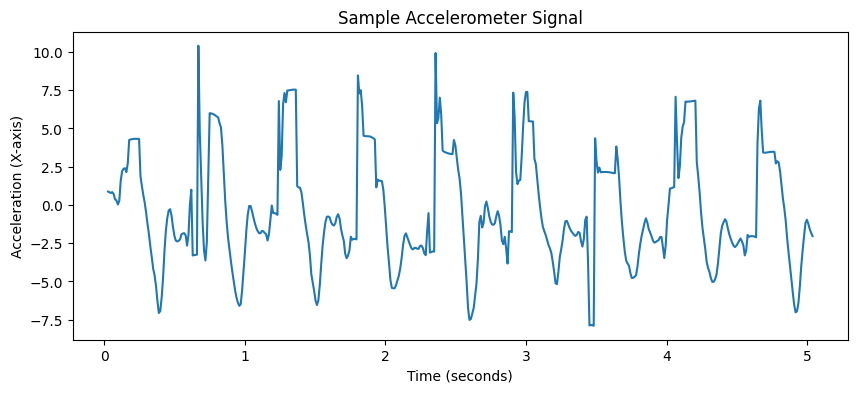

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df["seconds_elapsed_x"][:500], df["acc_x"][:500])
plt.title("Sample Accelerometer Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration (X-axis)")
plt.show()

## Feature Extraction
For each window, both time-domain and frequency-domain features are extracted from the accelerometer and gyroscope signals.

In [ ]:
#Features per window


from scipy.fft import rfft, rfftfreq
import numpy as np
import pandas as pd

feature_rows = []

for w in windows:

    window = w["data"]

    # Calculate acc_mag and gyro_mag for the current window
    window["acc_mag"] = np.sqrt(window["acc_x"]**2 + window["acc_y"]**2 + window["acc_z"]**2)
    window["gyro_mag"] = np.sqrt(window["gyro_x"]**2 + window["gyro_y"]**2 + window["gyro_z"]**2)

    acc = window["acc_mag"].values
    gyro = window["gyro_mag"].values

    #TIME DOMAIN FEATURES

    mean_acc = np.mean(acc)
    std_acc = np.std(acc)
    var_acc = np.var(acc)
    rms_acc = np.sqrt(np.mean(acc**2))
    sma_acc = np.mean(np.abs(acc))

    mean_gyro = np.mean(gyro)
    std_gyro = np.std(gyro)

    # FREQUENCY DOMAIN FEATURE

    fft_vals = np.abs(rfft(acc))
    freqs = rfftfreq(len(acc), 1/fs)

    dominant_freq = freqs[np.argmax(fft_vals)]
    spectral_energy = np.sum(fft_vals**2)

    feature_rows.append({
        "mean_acc": mean_acc,
        "std_acc": std_acc,
        "var_acc": var_acc,
        "rms_acc": rms_acc,
        "sma_acc": sma_acc,
        "mean_gyro": mean_gyro,
        "std_gyro": std_gyro,
        "dominant_freq": dominant_freq,
        "spectral_energy": spectral_energy,
        "activity": w["activity"],
        "session_id": w["session_id"]
    })

feature_df = pd.DataFrame(feature_rows)

print(feature_df.head())
print("Total feature samples:", len(feature_df))

   mean_acc   std_acc    var_acc    rms_acc   sma_acc  mean_gyro  std_gyro  \
0  8.833000  3.437361  11.815452   9.478256  8.833000   0.769209  0.309631   
1  9.451484  3.272357  10.708318  10.001943  9.451484   0.669347  0.294948   
2  9.040246  3.371230  11.365194   9.648381  9.040246   0.696151  0.375215   
3  9.149528  3.039566   9.238963   9.641205  9.149528   0.763833  0.439873   
4  9.657612  2.623292   6.881661  10.007554  9.657612   0.817725  0.442074   

   dominant_freq  spectral_energy activity  \
0            0.0    472104.053472  jumping   
1            0.0    532601.494185  jumping   
2            0.0    491673.659945  jumping   
3            0.0    496875.066089  jumping   
4            0.0    543995.421211  jumping   

                            session_id  
0  best_jumping_01-2026-03-04_18-42-01  
1  best_jumping_01-2026-03-04_18-42-01  
2  best_jumping_01-2026-03-04_18-42-01  
3  best_jumping_01-2026-03-04_18-42-01  
4  best_jumping_01-2026-03-04_18-42-01  
Total fe

## Feature Normalization
All features are normalized using standard scaling to ensure that each feature contributes equally during model training.

In [ ]:
#Normlizing features
from sklearn.preprocessing import StandardScaler

X = feature_df.drop(["activity","session_id"], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled["activity"] = feature_df["activity"].values
X_scaled["session_id"] = feature_df["session_id"].values

print(X_scaled.head())

   mean_acc   std_acc   var_acc   rms_acc   sma_acc  mean_gyro  std_gyro  \
0  1.488909  1.197217  0.705763  1.442479  1.488909   1.450454  0.824709   
1  1.641355  1.107131  0.592713  1.560443  1.641355   1.143763  0.747085   
2  1.539992  1.161113  0.659787  1.480801  1.539992   1.226081  1.171441   
3  1.566928  0.980037  0.442678  1.479184  1.566928   1.433944  1.513270   
4  1.692162  0.752768  0.201974  1.561706  1.692162   1.599454  1.524907   

   dominant_freq  spectral_energy activity  \
0            0.0         1.193705  jumping   
1            0.0         1.418073  jumping   
2            0.0         1.266283  jumping   
3            0.0         1.285574  jumping   
4            0.0         1.460330  jumping   

                            session_id  
0  best_jumping_01-2026-03-04_18-42-01  
1  best_jumping_01-2026-03-04_18-42-01  
2  best_jumping_01-2026-03-04_18-42-01  
3  best_jumping_01-2026-03-04_18-42-01  
4  best_jumping_01-2026-03-04_18-42-01  


In [ ]:
#Training

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

# prepare X
X = feature_df.drop(["activity", "session_id"], axis=1)

scaler = StandardScaler()
X_scaled_features = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_features, columns=X.columns)
X_scaled["activity"] = feature_df["activity"].values
X_scaled["session_id"] = feature_df["session_id"].values

# sequence lengths per session
lengths = X_scaled.groupby("session_id").size().tolist()

# training array
X_train = X_scaled.drop(["activity", "session_id"], axis=1).values

# HMM
model = GaussianHMM(
    n_components=4,
    covariance_type="diag",
    n_iter=200,
    tol=1e-3,
    random_state=42
)

model.fit(X_train, lengths=lengths)

print("HMM trained successfully")
print("Converged:", model.monitor_.converged)
print("Iterations:", model.monitor_.iter)
print("Final log-likelihood:", model.monitor_.history[-1])

HMM trained successfully
Converged: True
Iterations: 12
Final log-likelihood: 15966.721303292448


## Hidden Markov Model Training
A Gaussian Hidden Markov Model with four hidden states is trained using the extracted features. The Baum–Welch algorithm is used for parameter optimization.

In [ ]:
states = model.predict(X_train)

print(states[:20])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


## Transition Matrix Visualization

The transition matrix shows the probability of transitioning from one hidden state to another in the Hidden Markov Model. This helps visualize how the model moves between states representing different activity patterns.

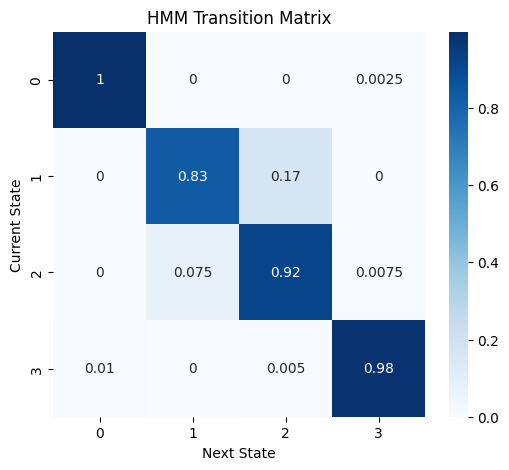

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(model.transmat_, annot=True, cmap="Blues")

plt.title("HMM Transition Matrix")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.show()

## Hidden State Sequence Visualization

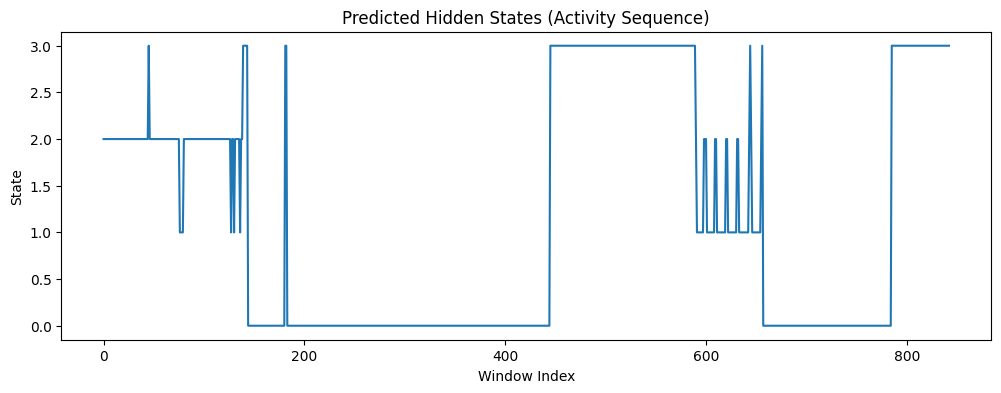

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(states)
plt.title("Predicted Hidden States (Activity Sequence)")
plt.xlabel("Window Index")
plt.ylabel("State")
plt.show()

## Load Unseen Test Data

To evaluate the generalization ability of the trained Hidden Markov Model, a separate test dataset is loaded.  
These recordings were collected in a different session and were not used during model training.

In [ ]:
import pandas as pd

test_df = pd.read_csv("TEST_MERGED/all_merged_sessions.csv")

print(test_df.head())
print(test_df.columns)
print(test_df["activity"].value_counts())

                  time  seconds_elapsed_x     acc_x     acc_y     acc_z  \
0  1772827810915355100           0.066355  0.056772 -0.023253 -0.008219   
1  1772827810925395200           0.076395  0.054585 -0.016232 -0.007231   
2  1772827810935435300           0.086435  0.049496  0.004943  0.029729   
3  1772827810945475300           0.096475  0.019227  0.022612  0.016396   
4  1772827810955516400           0.106516 -0.033995  0.040556  0.013500   

   seconds_elapsed_y    gyro_x    gyro_y    gyro_z member activity  \
0           0.066355 -0.067695 -0.033524 -0.033961   best  jumping   
1           0.076395 -0.065733 -0.032823 -0.033513   best  jumping   
2           0.086435 -0.063070 -0.033118 -0.034086   best  jumping   
3           0.096475 -0.056658 -0.037683 -0.036166   best  jumping   
4           0.106516 -0.053768 -0.037270 -0.038727   best  jumping   

                         trial                             session_id  
0  jumping-2026-03-06_20-10-10  best_test_jumping-2026-0

## Window Segmentation for Test Data

The same window segmentation process used for the training data is applied to the unseen test dataset.

In [ ]:
fs = 75
window_size = int(fs * 1)
step_size = int(window_size * 0.5)   # 50% overlap

test_windows = []

for session_id, session_df in test_df.groupby("session_id"):
    session_df = session_df.sort_values("seconds_elapsed_x").reset_index(drop=True)

    for start in range(0, len(session_df) - window_size + 1, step_size):
        end = start + window_size
        window = session_df.iloc[start:end].copy()

        test_windows.append({
            "session_id": session_id,
            "member": window["member"].iloc[0],
            "activity": window["activity"].iloc[0],
            "trial": window["trial"].iloc[0],
            "window_index": len(test_windows),
            "data": window
        })

print("Total test windows created:", len(test_windows))
print("First test window activity:", test_windows[0]["activity"])
print("First test window session:", test_windows[0]["session_id"])

Total test windows created: 153
First test window activity: jumping
First test window session: best_test_jumping-2026-03-06_20-10-10


In [ ]:
from scipy.fft import rfft, rfftfreq
import numpy as np
import pandas as pd

test_feature_rows = []

for w in test_windows:
    window = w["data"].copy()

    # Calculate magnitudes
    window["acc_mag"] = np.sqrt(window["acc_x"]**2 + window["acc_y"]**2 + window["acc_z"]**2)
    window["gyro_mag"] = np.sqrt(window["gyro_x"]**2 + window["gyro_y"]**2 + window["gyro_z"]**2)

    acc = window["acc_mag"].values
    gyro = window["gyro_mag"].values

    # Time-domain features
    mean_acc = np.mean(acc)
    std_acc = np.std(acc)
    var_acc = np.var(acc)
    rms_acc = np.sqrt(np.mean(acc**2))
    sma_acc = np.mean(np.abs(acc))

    mean_gyro = np.mean(gyro)
    std_gyro = np.std(gyro)

    # Frequency-domain features
    fft_vals = np.abs(rfft(acc))
    freqs = rfftfreq(len(acc), 1/fs)

    dominant_freq = freqs[np.argmax(fft_vals)]
    spectral_energy = np.sum(fft_vals**2)

    test_feature_rows.append({
        "mean_acc": mean_acc,
        "std_acc": std_acc,
        "var_acc": var_acc,
        "rms_acc": rms_acc,
        "sma_acc": sma_acc,
        "mean_gyro": mean_gyro,
        "std_gyro": std_gyro,
        "dominant_freq": dominant_freq,
        "spectral_energy": spectral_energy,
        "activity": w["activity"],
        "session_id": w["session_id"]
    })

test_feature_df = pd.DataFrame(test_feature_rows)

print(test_feature_df.head())
print("Total test feature samples:", len(test_feature_df))
print(test_feature_df["activity"].value_counts())

    mean_acc   std_acc    var_acc    rms_acc    sma_acc  mean_gyro  std_gyro  \
0   4.616679  4.439057  19.705224   6.404604   4.616679   0.561473  0.421334   
1   9.448774  3.861432  14.910656  10.207349   9.448774   0.756446  0.444952   
2  11.440271  3.239132  10.491974  11.889986  11.440271   1.206676  0.643948   
3  11.535975  4.604082  21.197572  12.420801  11.535975   1.498544  0.774614   
4  10.270537  5.033448  25.335597  11.437637  10.270537   1.114761  0.780817   

   dominant_freq  spectral_energy activity  \
0            0.0    175310.660565  jumping   
1            0.0    544132.418604  jumping   
2            0.0    765707.502767  jumping   
3            0.0    808186.009117  jumping   
4            0.0    664603.524365  jumping   

                              session_id  
0  best_test_jumping-2026-03-06_20-10-10  
1  best_test_jumping-2026-03-06_20-10-10  
2  best_test_jumping-2026-03-06_20-10-10  
3  best_test_jumping-2026-03-06_20-10-10  
4  best_test_jumping-2026-0

In [ ]:
# Separate features and labels
X_test = test_feature_df.drop(["activity", "session_id"], axis=1)
y_test = test_feature_df["activity"].values

# Used the SAME scaler from training
X_test_scaled = scaler.transform(X_test)

print(X_test_scaled[:5])

[[0.4496591  1.74410293 1.51138635 0.75011932 0.4496591  0.81246183
  1.41526212 0.         0.09298492]
 [1.640687   1.42874293 1.02181356 1.60671175 1.640687   1.41125762
  1.54012157 0.         1.46083767]
 [2.13155664 1.08899188 0.57062234 1.98573627 2.13155664 2.79399147
  2.59217519 0.         2.28259529]
 [2.15514621 1.83420021 1.66376984 2.10530573 2.15514621 3.69036666
  3.28297697 0.         2.44013573]
 [1.84323759 2.06861673 2.08630316 1.88384178 1.84323759 2.51170281
  3.31576855 0.         1.90763001]]


In [ ]:
test_states = model.predict(X_test_scaled)
print(test_states[:20])

[2 2 1 1 1 2 2 1 1 1 1 2 1 1 1 2 1 2 2 2]


In [ ]:
train_results = pd.DataFrame({
    "true_activity": X_scaled["activity"].values,
    "predicted_state": states
})

state_activity_map = (
    train_results.groupby("predicted_state")["true_activity"]
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)

print(state_activity_map)

{0: 'still', 1: 'jumping', 2: 'jumping', 3: 'walking'}


In [ ]:
y_pred = [state_activity_map[s] for s in test_states]
print(y_pred[:20])

['jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping', 'jumping']


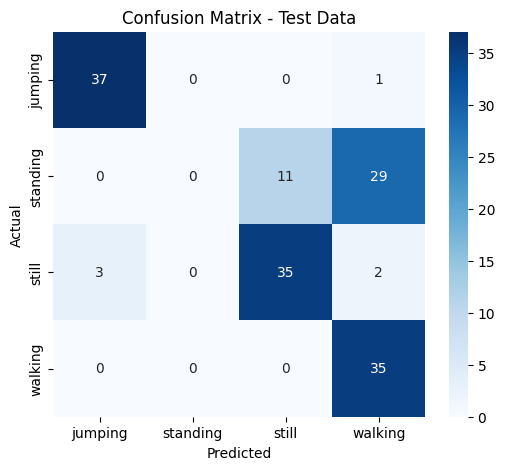

Overall Accuracy: 0.6993464052287581


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(test_feature_df["activity"].unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Data")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("Overall Accuracy:", accuracy)

### Confusion Matrix Interpretation

The confusion matrix shows how well the model predicted each activity on the test data. The model correctly identified most of the **jumping** and **walking** activities. The **still** activity was also predicted correctly most of the time, with only a few mistakes. However, the model had difficulty recognizing **standing**, and many standing samples were predicted as still or walking. This is likely because standing and still have very similar sensor patterns.

### Model Accuracy

The model achieved an overall accuracy of about **70%** on the unseen test dataset. This shows that the Hidden Markov Model was able to recognize most of the activities correctly, although it struggled to clearly distinguish between some low-movement activities such as standing and still.